In [1]:
for t in trials:
    if t['cs'] and t['ce']:
        print(
            f"T{t['num']}: "
            f"CS={t['cs']:.0f} ms, "
            f"CE={t['ce']:.0f} ms, "
            f"Δ={(t['ce'] - t['cs']):.0f} ms"
        )

NameError: name 'trials' is not defined

Subject 6  |  Session 1  |  03-05-2026
Anchor: tick=798,750  Welcome=90,205  OFFSET=708,545
mA range: 0.00→0.60  |  Last stim: 258.0s

Digit sequences per trial:
  T1: [4, 1]
  T2: [2, 3]
  T3: [5, 2, 3]
  T4: [1, 5, 4]
  T5: [5, 1, 3, 2]
  T6: [4, 1, 4, 3]
  T7: [5, 2, 4, 2]
  T8: [1, 5, 3, 5]
  T9: [1, 2, 4, 3]
  T10: [1, 4, 2, 5]
  T11: [3, 2, 1, 5]
  T12: [4, 3, 1, 2]
  T13: [4, 3, 5, 2, 1]
  T14: [5, 4, 3, 5, 4]

Session: t=0s → 256.8s  |  Drift: 1.2s
  T01  2dig  OK  digits=[4, 1]  CRESP=14  RESP=14
  T02  2dig  OK  digits=[2, 3]  CRESP=32  RESP=32
  T03  3dig  OK  digits=[5, 2, 3]  CRESP=325  RESP=325
  T04  3dig  OK  digits=[1, 5, 4]  CRESP=451  RESP=451
  T05  4dig  OK  digits=[5, 1, 3, 2]  CRESP=2315  RESP=2315
  T06  4dig  X  digits=[4, 1, 4, 3]  CRESP=3414  RESP=3415
  T07  4dig  X  digits=[5, 2, 4, 2]  CRESP=2425  RESP=2514
  T08  4dig  X  digits=[1, 5, 3, 5]  CRESP=5351  RESP=5314
  T09  4dig  X  digits=[1, 2, 4, 3]  CRESP=3421  RESP=3414
  T10  4dig  OK  digits=[1, 4, 2,

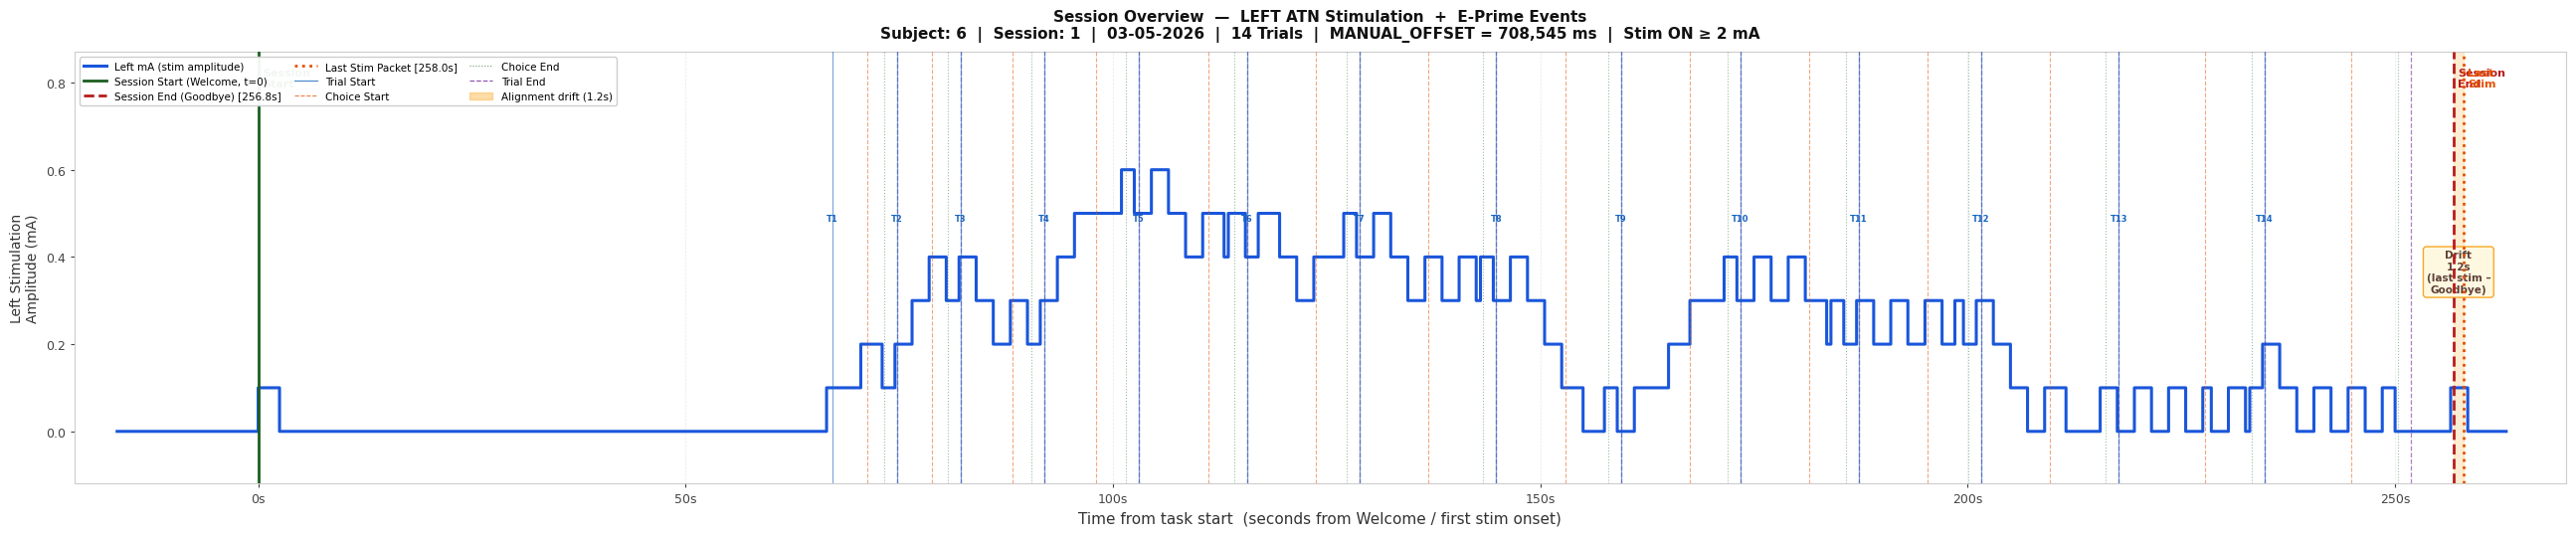

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1\plot1_session_overview.png


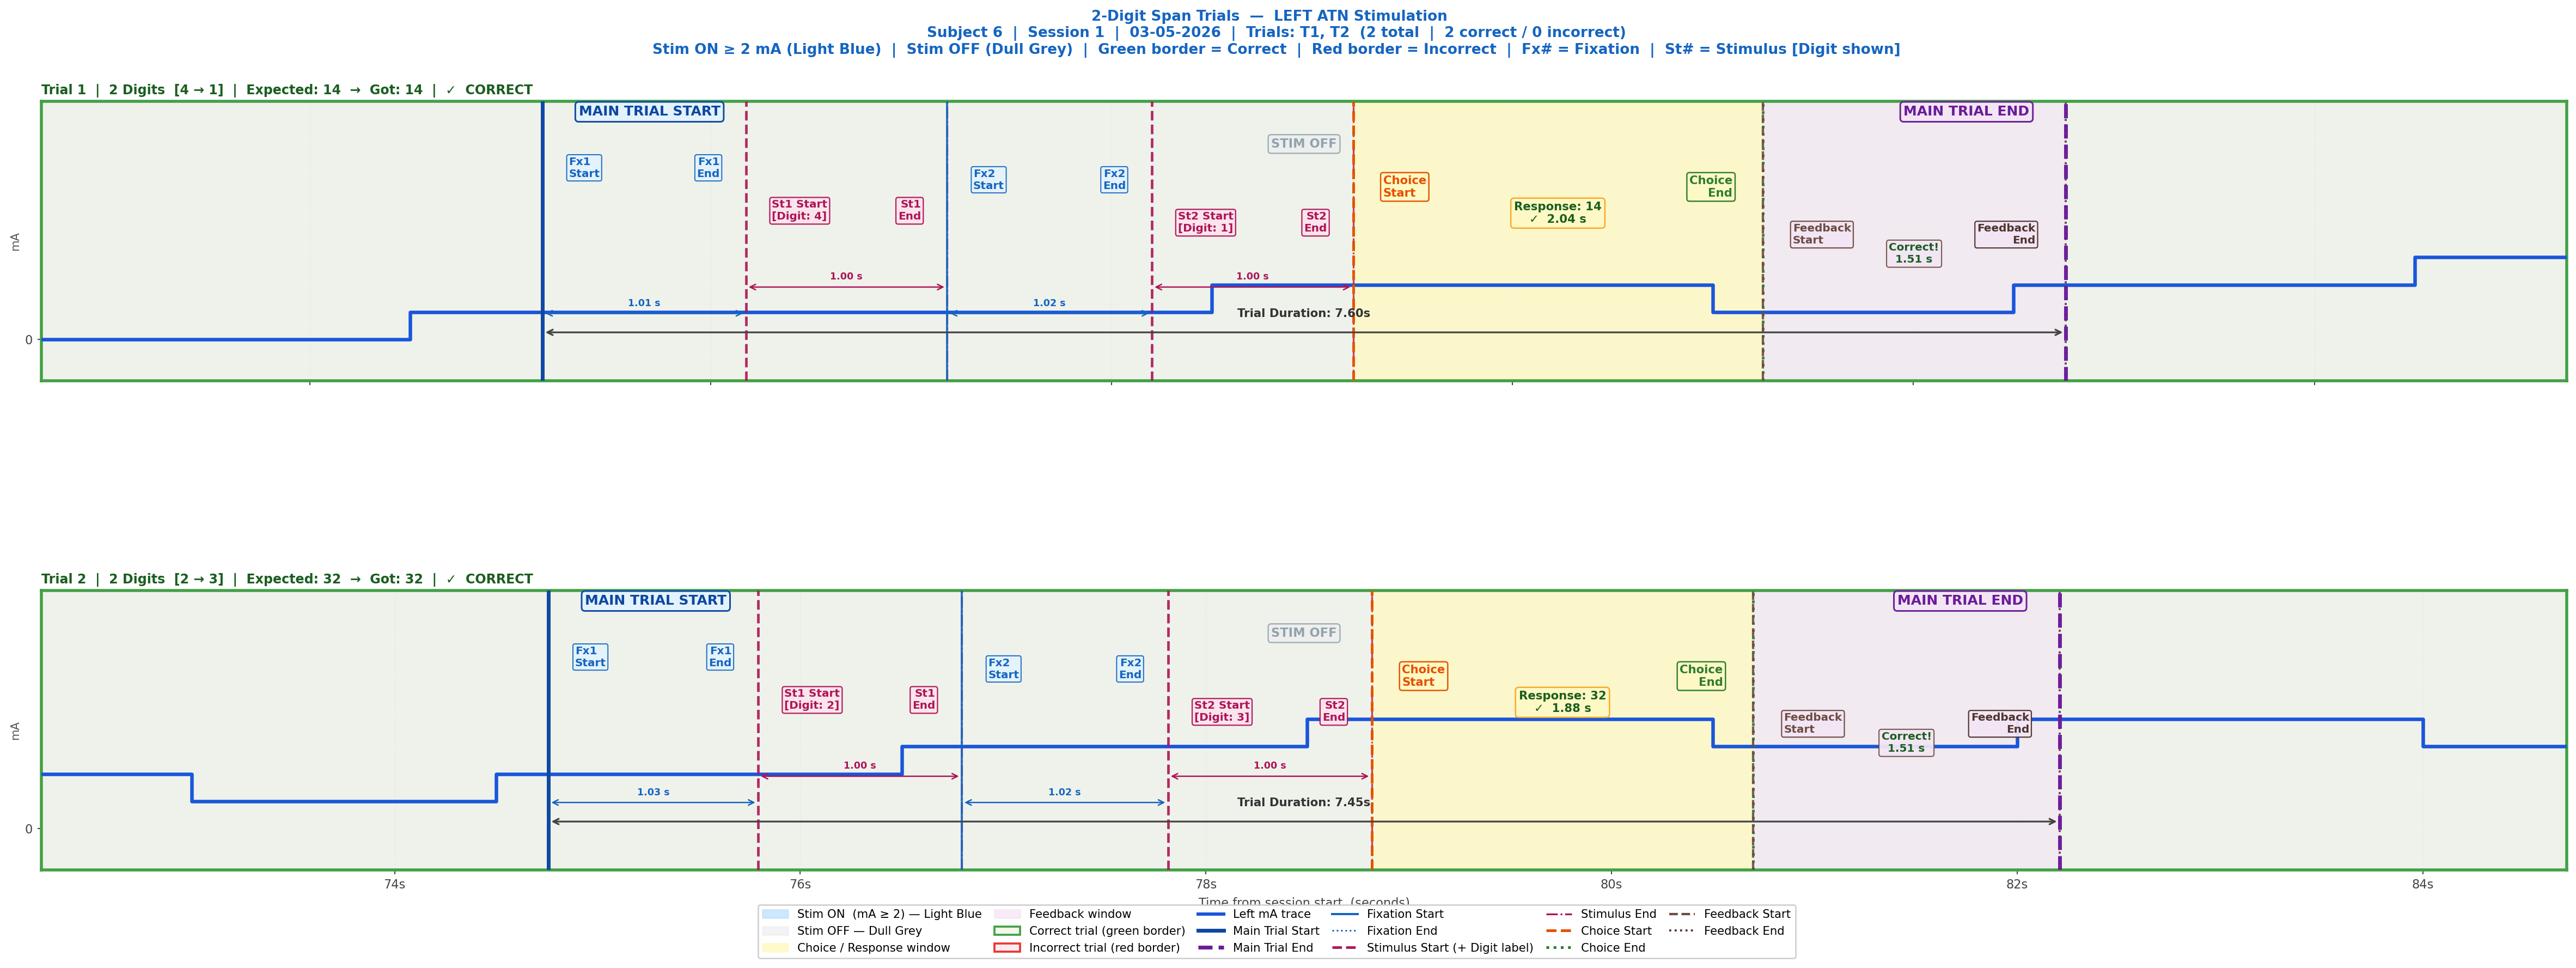

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1\plot_2digit.png  (2 trials: T1, T2)


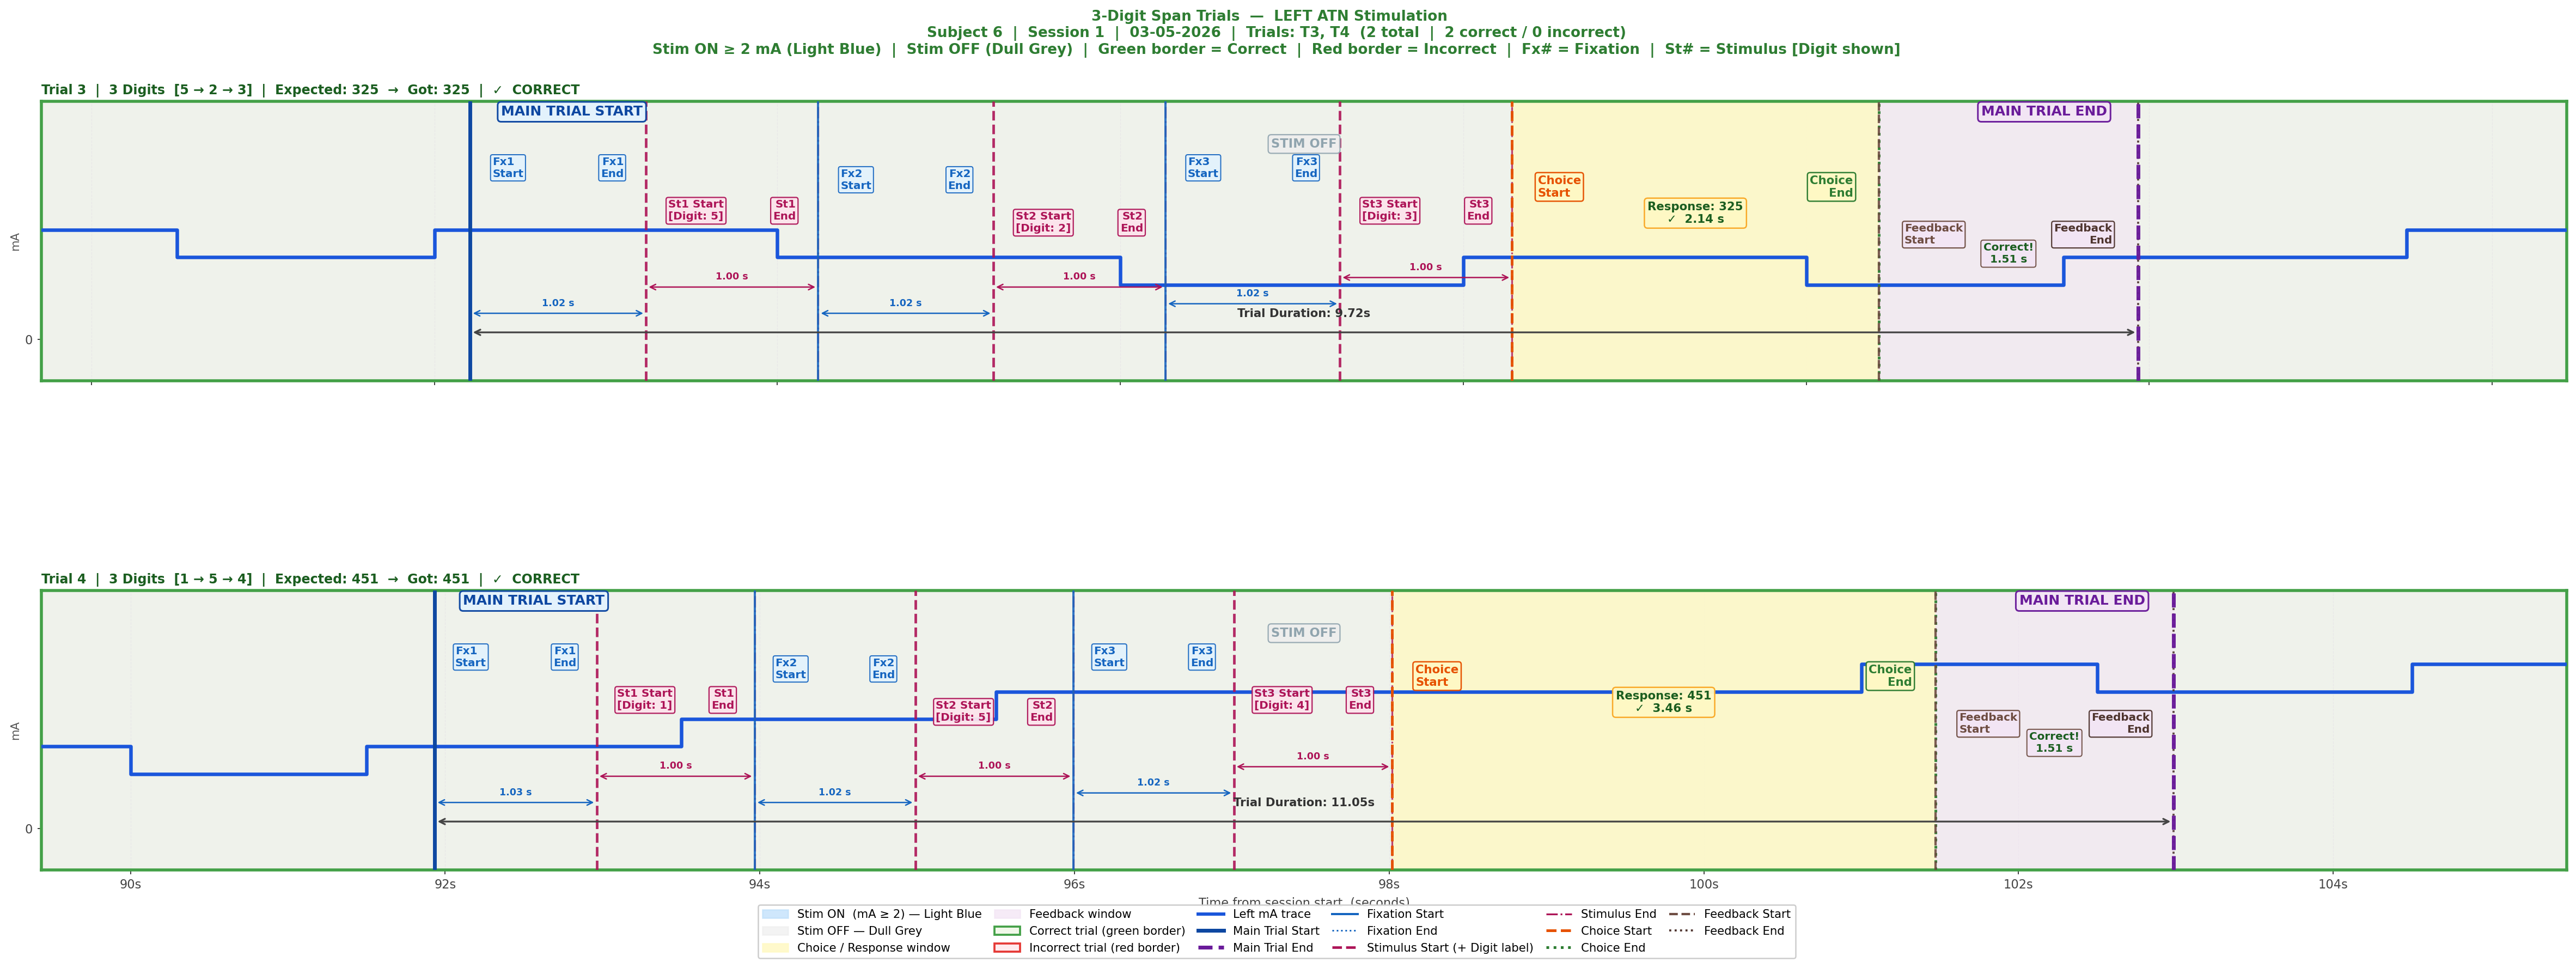

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1\plot_3digit.png  (2 trials: T3, T4)


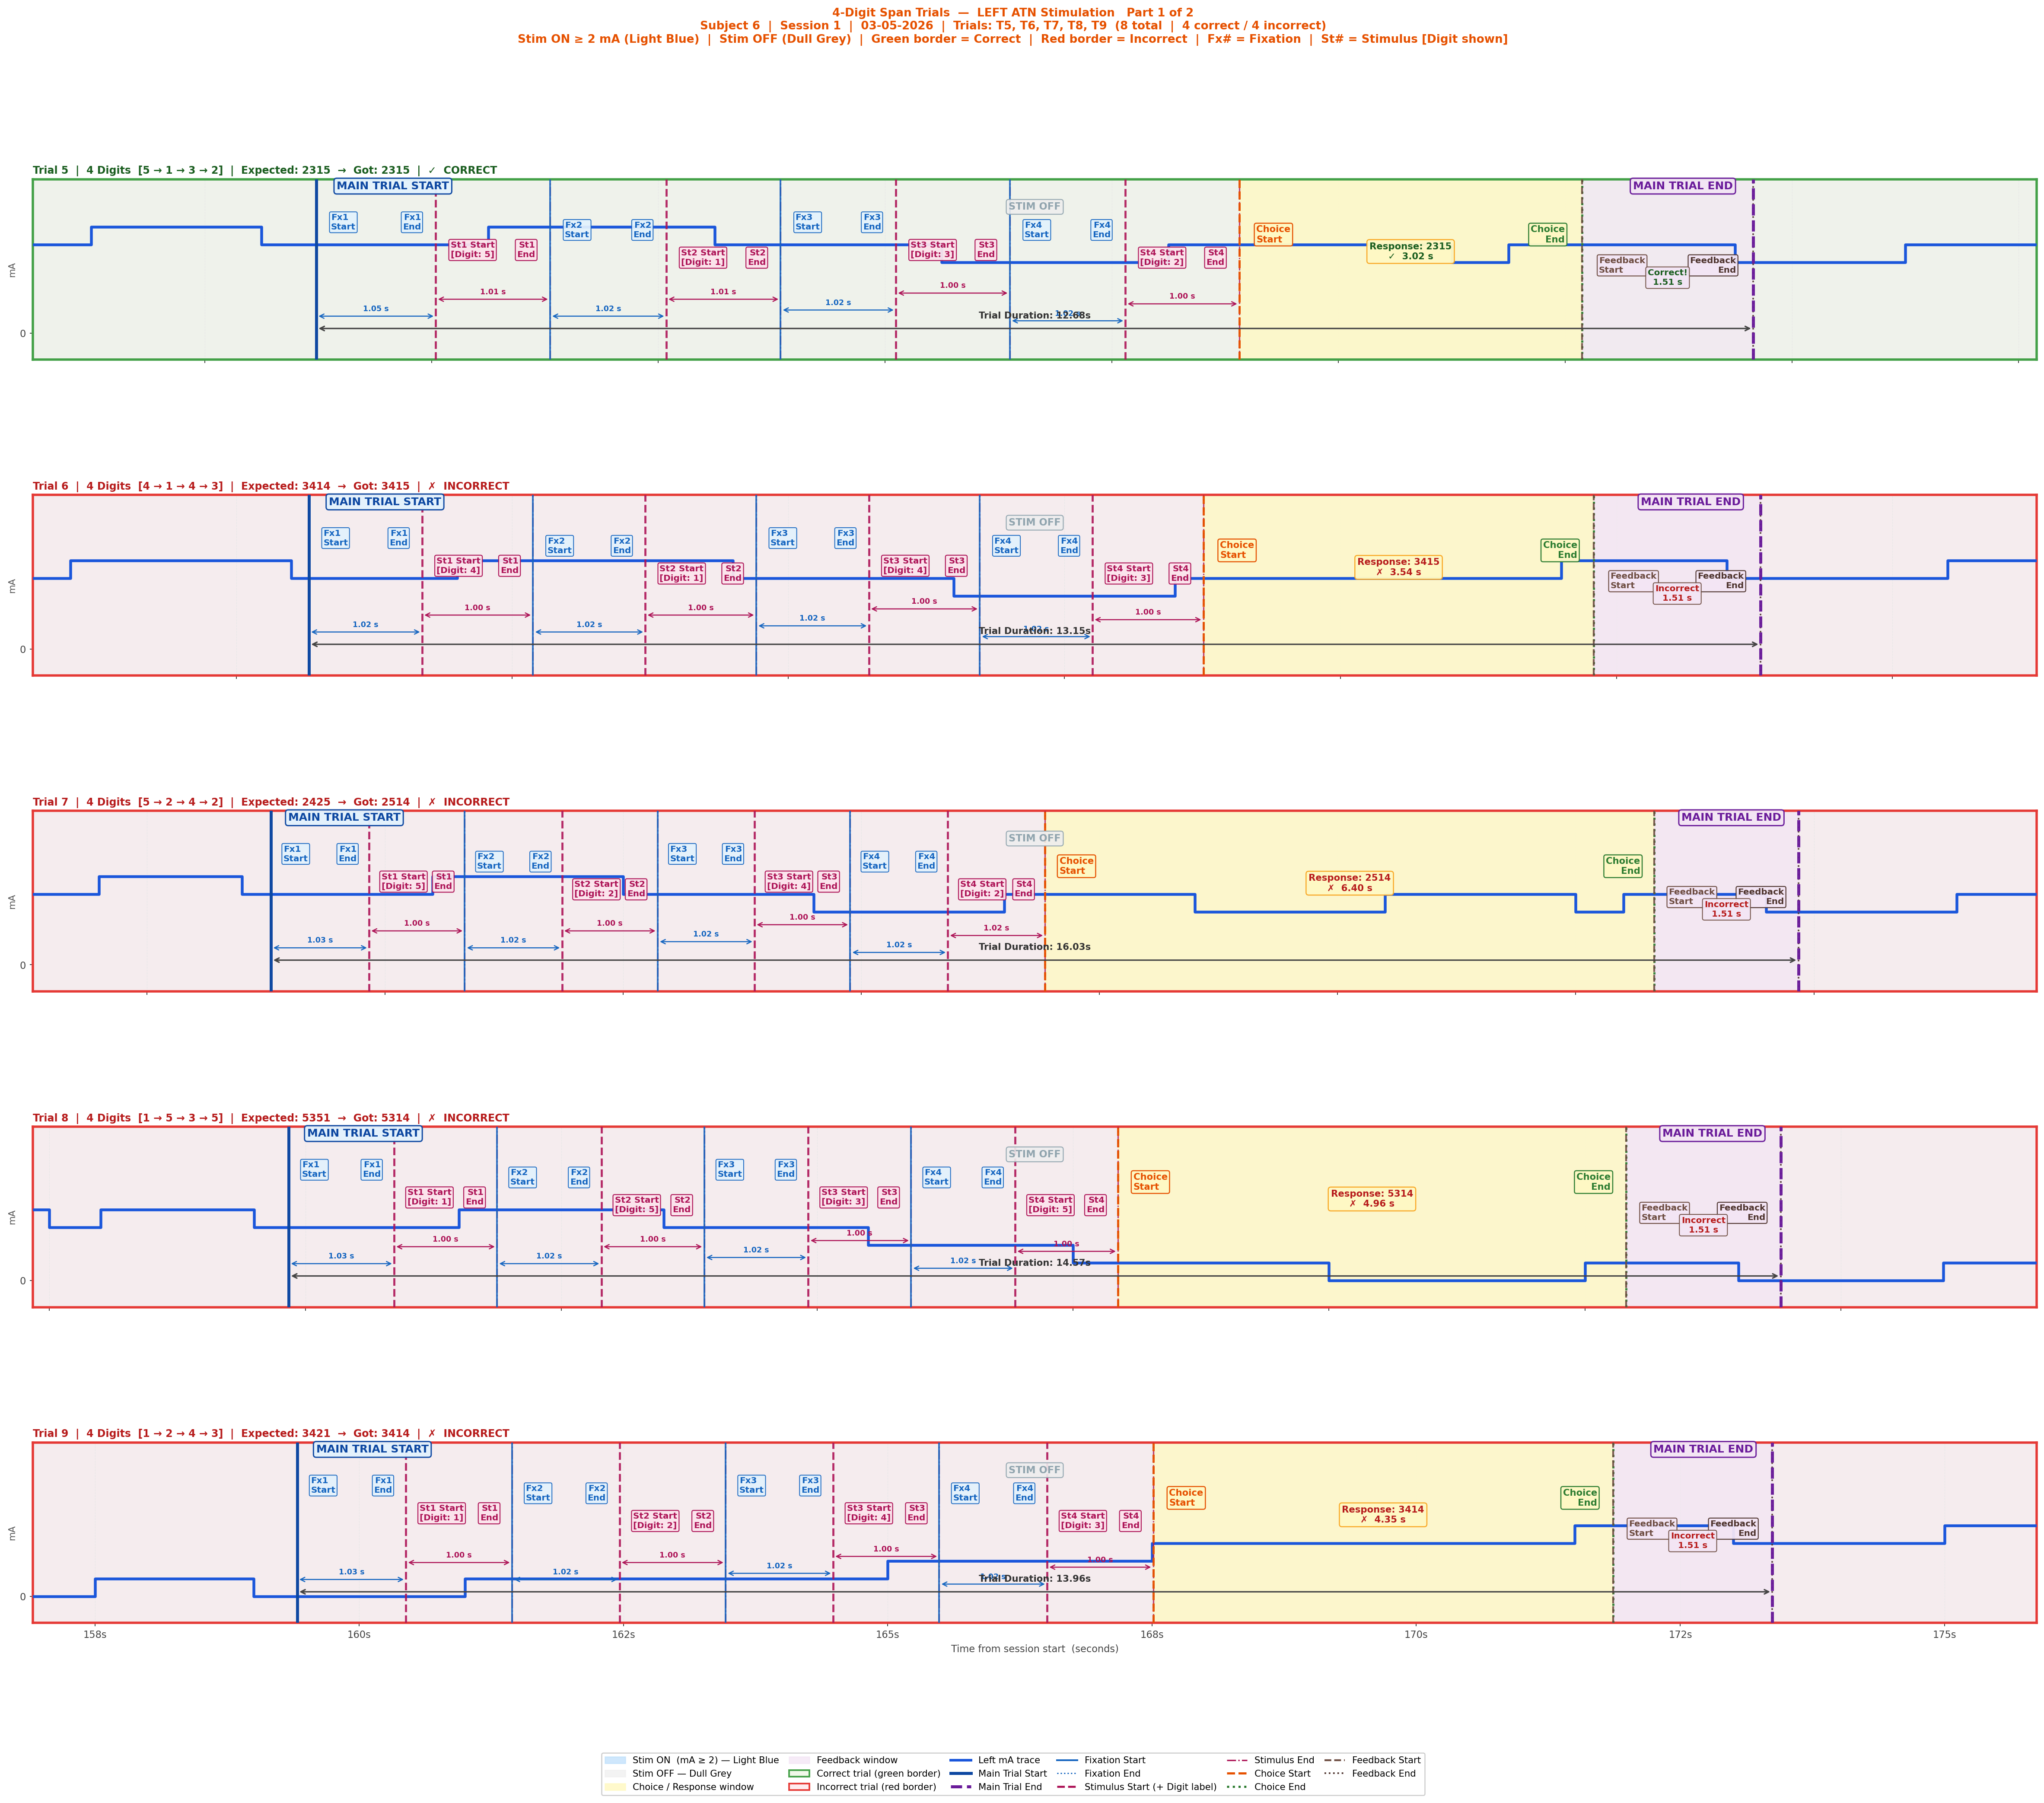

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1\plot_4digit_part1.png  (5 trials: T5, T6, T7, T8, T9)


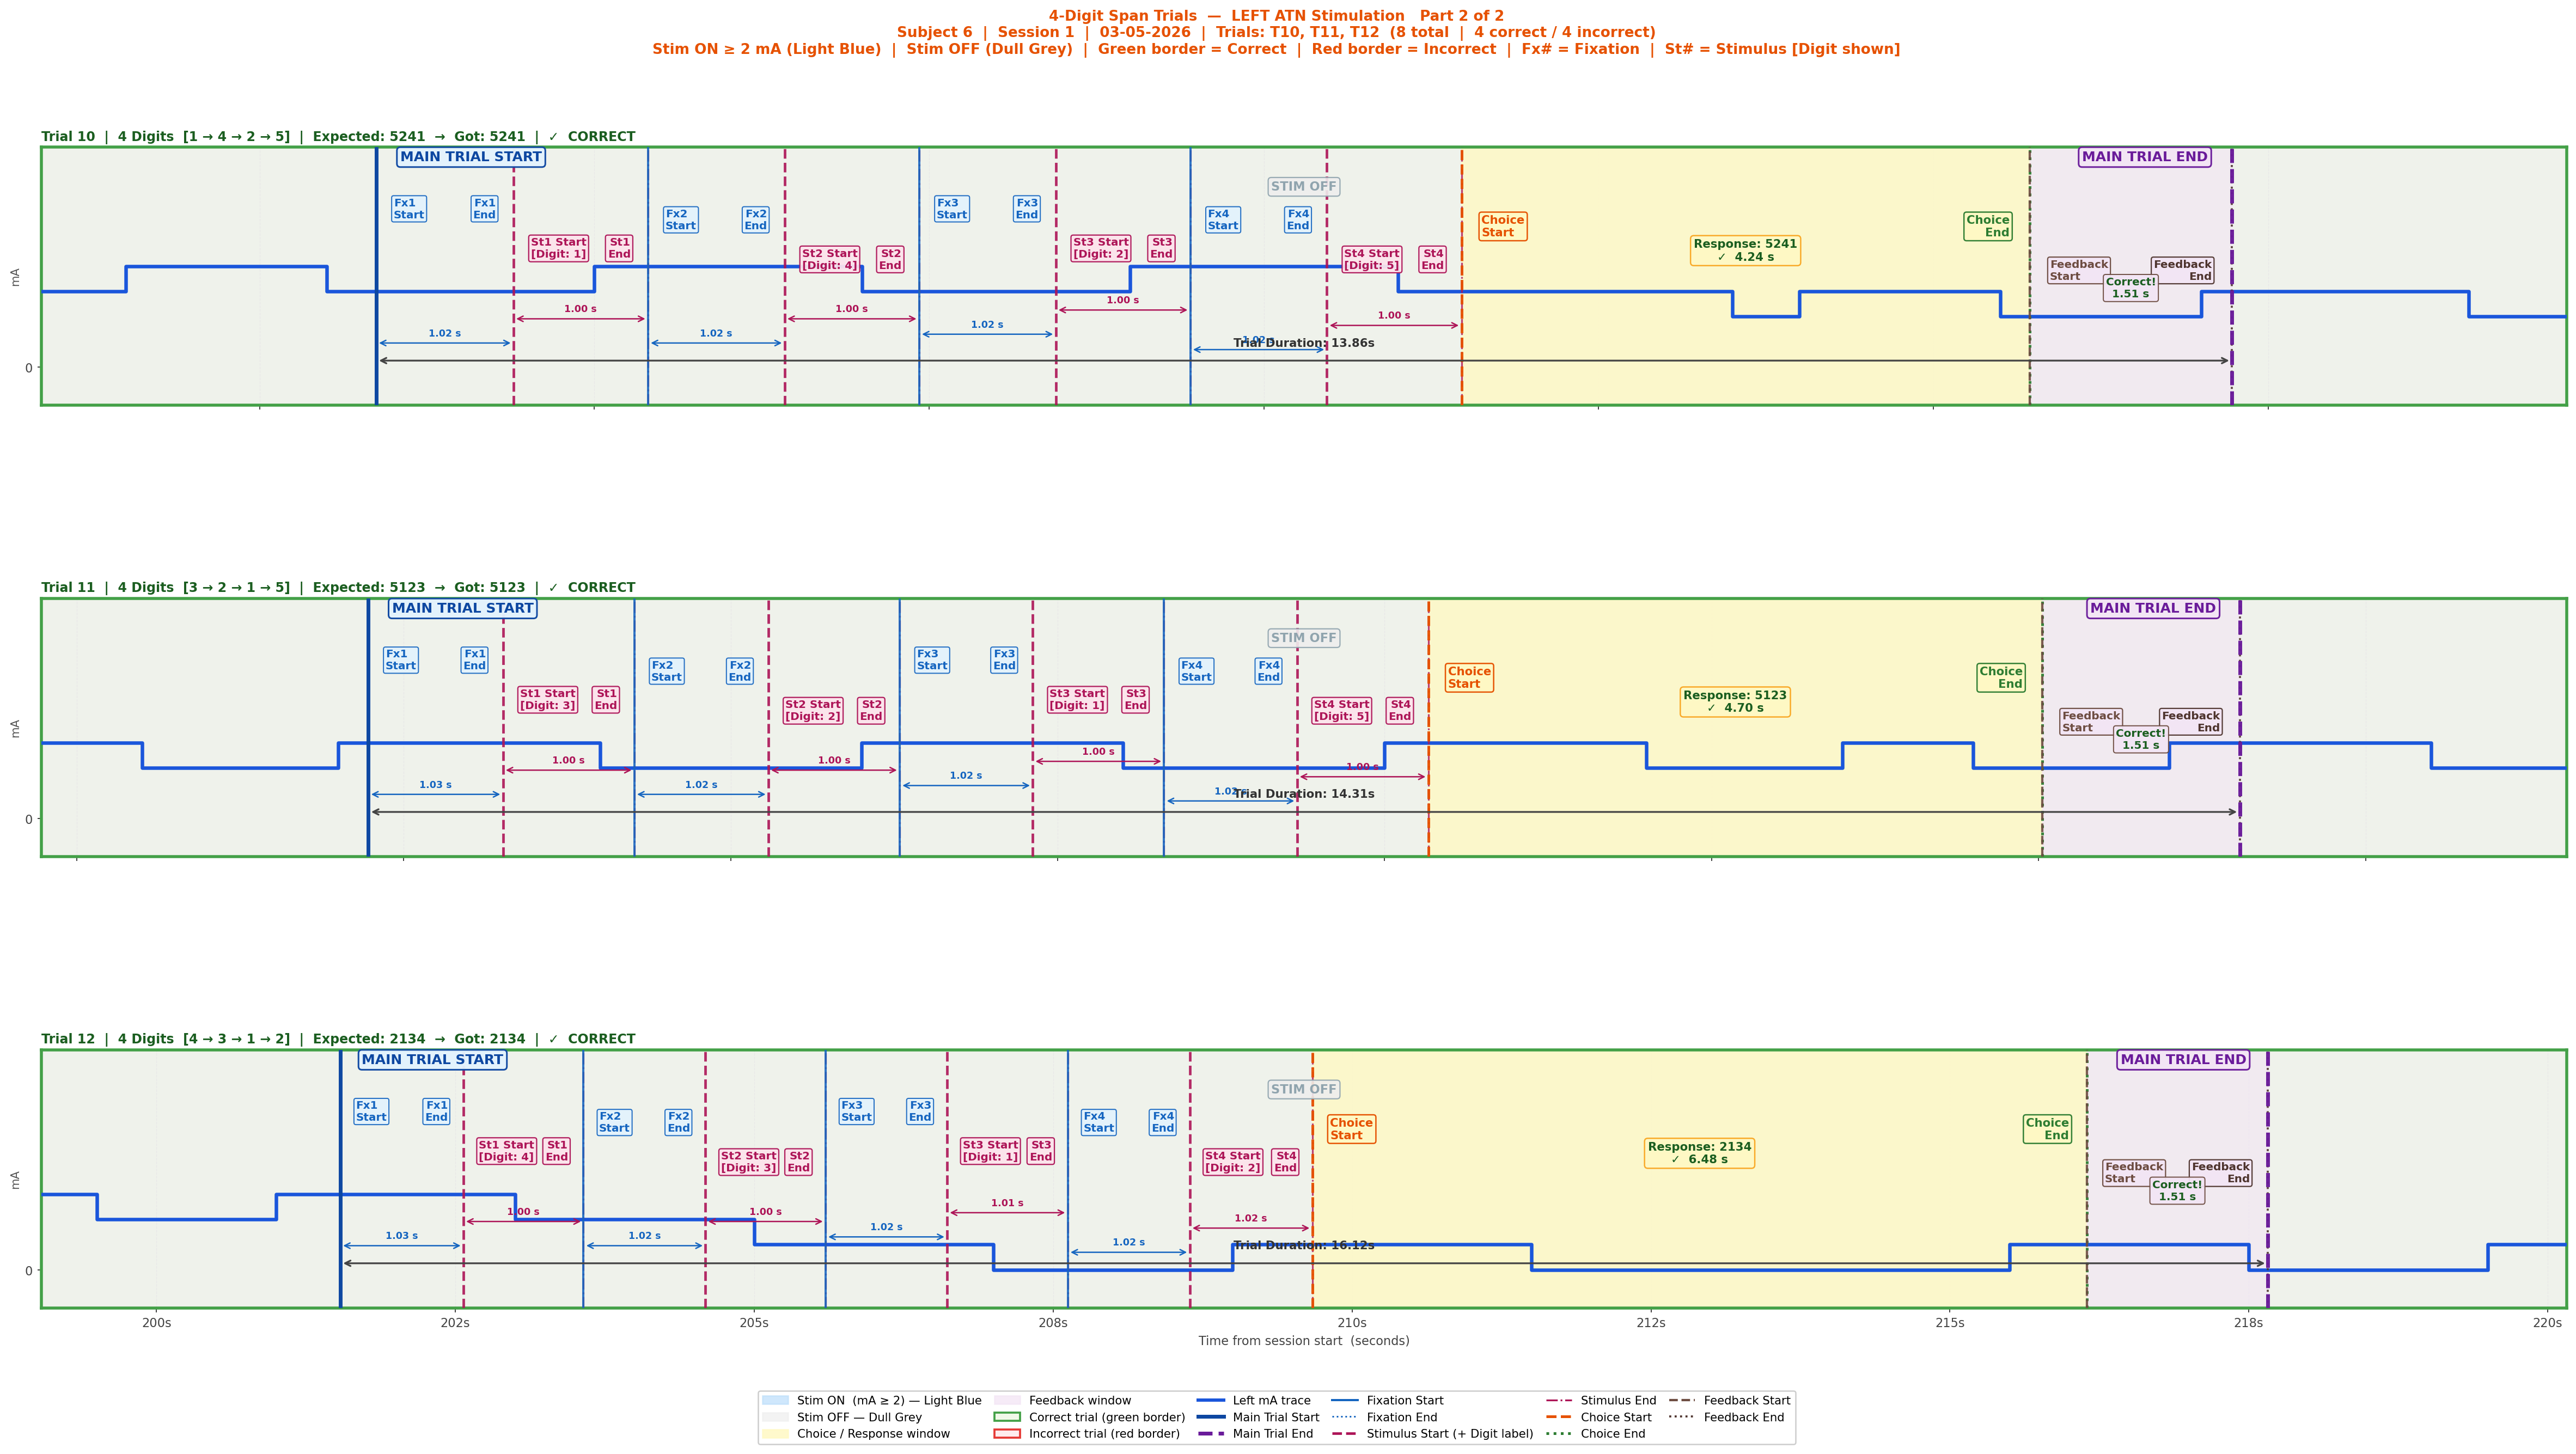

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1\plot_4digit_part2.png  (3 trials: T10, T11, T12)


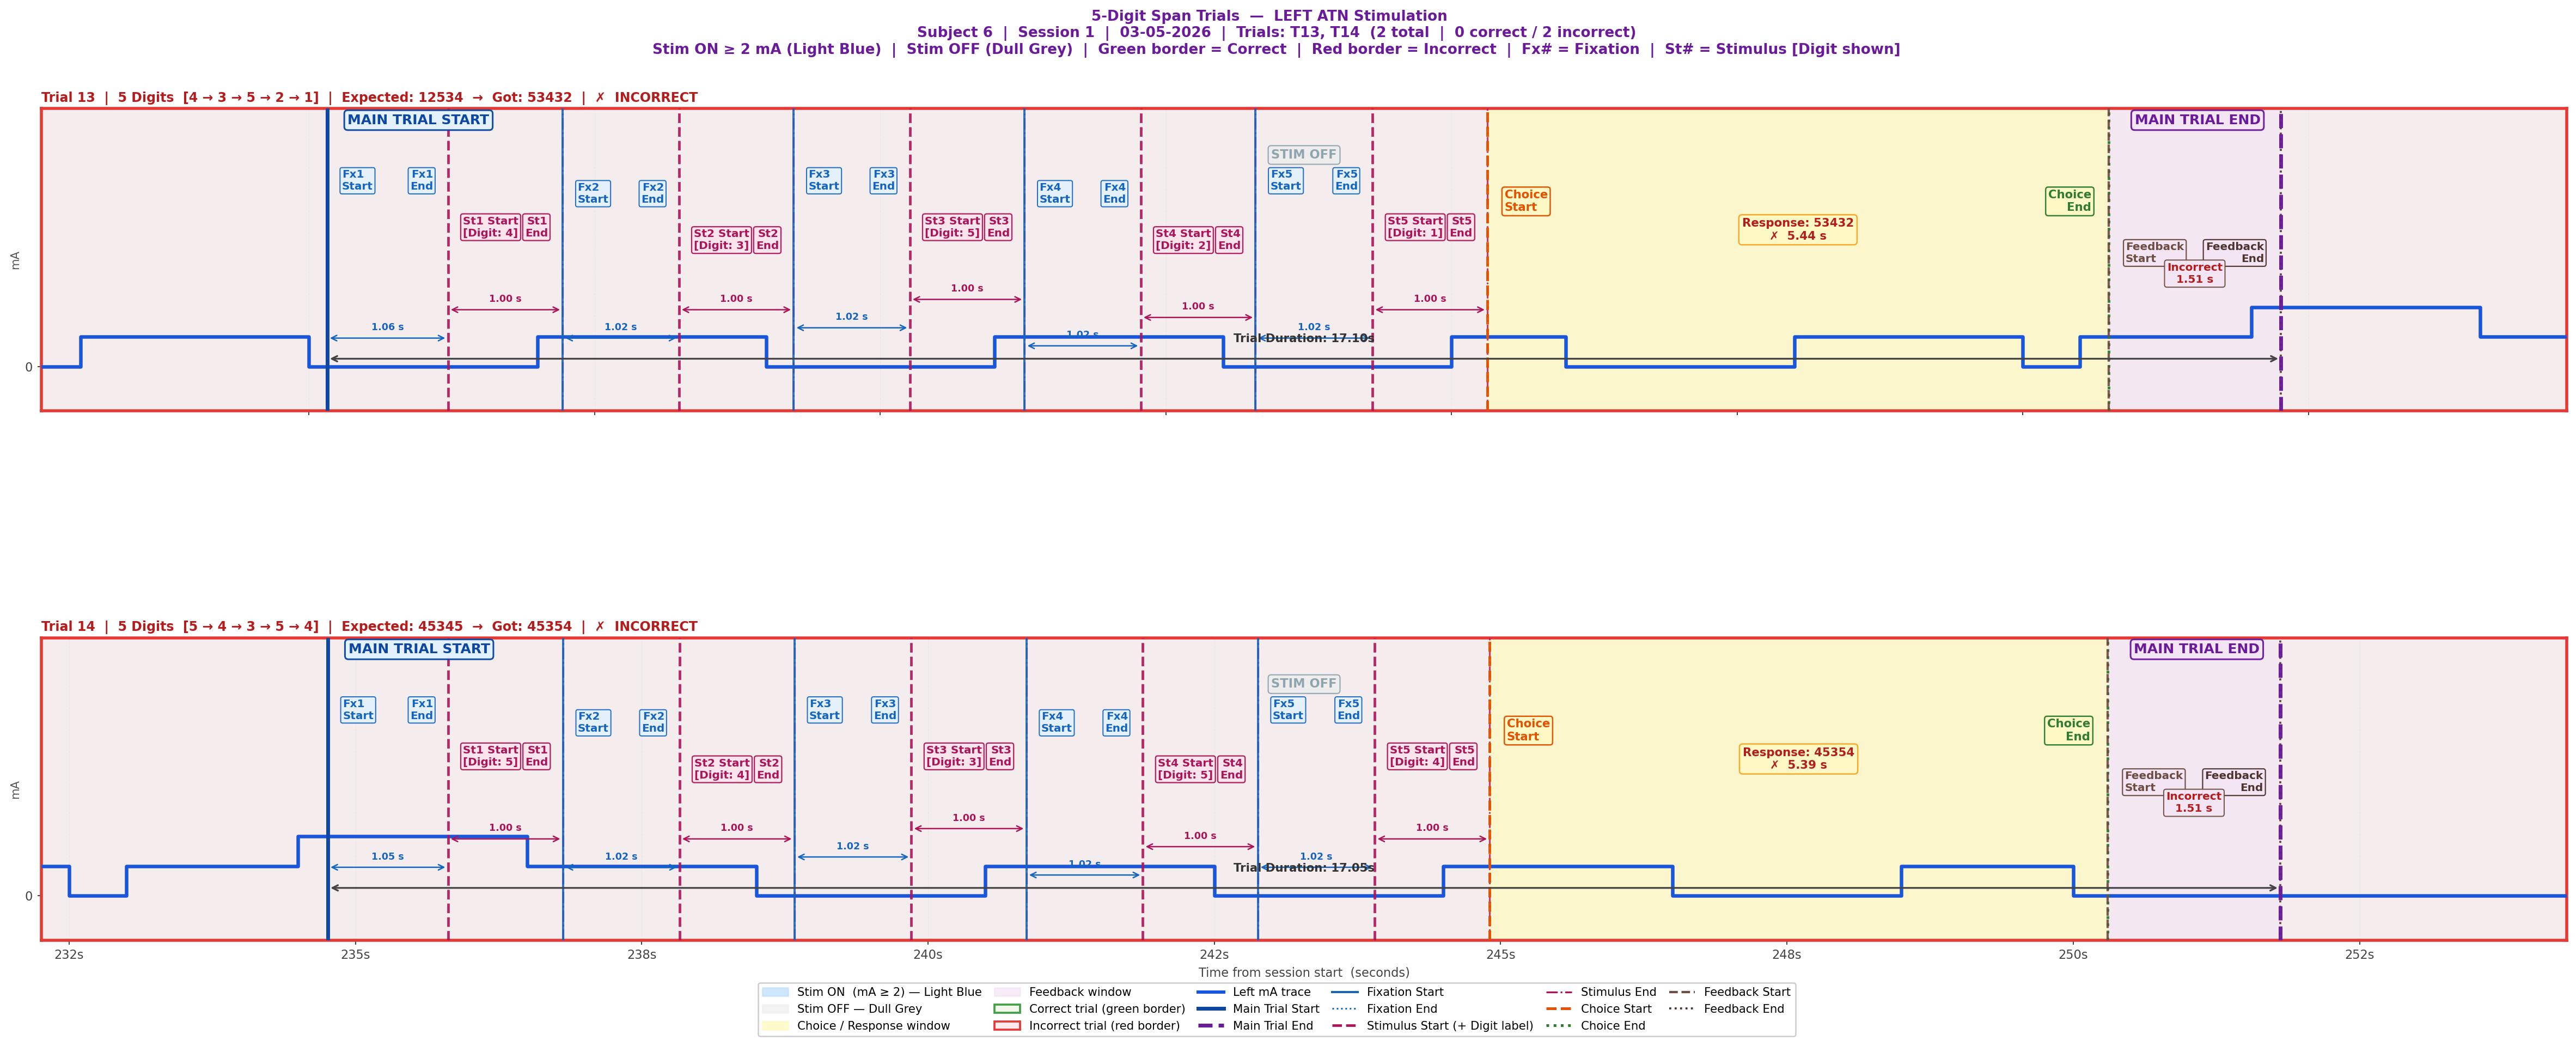

Saved → C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1\plot_5digit.png  (2 trials: T13, T14)

=== ALL DONE ===
  C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1\plot_2digit.png
  C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1\plot_3digit.png
  C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1\plot_4digit_part1.png
  C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1\plot_4digit_part2.png
  C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1\plot_5digit.png


In [2]:
"""
lfp_eprime_plots_v6.py
======================
Per-trial LFP plots with SEQUENTIAL event marker timeline showing:
  Main Trial Start
  → Fx1 Start – ~14ms – Fx1 End
  → St1 Start (Digit X) – ~1000ms – St1 End
  → Fx2 Start – ~14ms – Fx2 End
  → St2 Start (Digit Y) – ~1000ms – St2 End
  → ... (for 3 or 4 digit trials)
  → Choice Start – response time – Choice End  [resp shown]
  → Feedback Start – feedback duration – Feedback End
  → Main Trial End

STIM THRESHOLD = 2.0 mA  (shade light blue when mA >= 2, dull grey otherwise)
Border = GREEN (correct), RED (incorrect)

Alignment: first Left mA 0→>0 transition = Welcome.TargetOnsetTime

Dependencies: pip install pandas numpy matplotlib
"""

# =============================================================================
# 1. IMPORTS & FILE PATHS  ← EDIT THESE
# =============================================================================
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, MultipleLocator
from pathlib import Path

# ── EDIT THESE ───────────────────────────────────────────────────────────────
JSON_PATH   = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1426\Report_Json_Session_Report_20260305T151332.json")
CSV_PATH    = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-1-Scores.csv")
EVENTS_PATH = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1\Preprocessed Data\Events.csv")
OUT_PATH_1  = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1\plot1_session_overview.png")
OUT_DIR     = Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 1")
# ─────────────────────────────────────────────────────────────────────────────

OUT_DIR.mkdir(parents=True, exist_ok=True)

STIM_THRESHOLD     = 2.0   # mA — stim ON when Left mA >= this value
MAX_TRIALS_PER_FIG = 5     # paginate after this many rows per figure

# =============================================================================
# 2. LOAD DATA
# =============================================================================
with open(JSON_PATH) as f:
    report = json.load(f)

df = pd.read_csv(CSV_PATH,    encoding='utf-8-sig', low_memory=False)
ev = pd.read_csv(EVENTS_PATH, encoding='utf-8-sig', low_memory=False)

subject = str(df['Subject'].iloc[0])
session = str(df['Session'].iloc[0])
date    = str(df['SessionDate'].iloc[0])
print(f"Subject {subject}  |  Session {session}  |  {date}")

# =============================================================================
# 3. ALIGNMENT ANCHOR  (first Left mA  0 → >0 transition)
# =============================================================================
stim_start_tick = None
for stream in report['BrainSenseLfp']:
    prev = None
    for pkt in stream['LfpData']:
        curr = pkt['Left']['mA']
        if prev is not None and prev == 0.0 and curr > 0.0:
            stim_start_tick = pkt['TicksInMs']
            break
        prev = curr
    if stim_start_tick is not None:
        break
assert stim_start_tick, "ERROR: No 0→>0 mA transition found in BrainSenseLfp!"

welcome_ms    = int(df['Welcome.TargetOnsetTime'].iloc[0])
goodbye_ms    = int(df['Goodbye.FinishTime'].iloc[0])
MANUAL_OFFSET = stim_start_tick - welcome_ms
print(f"Anchor: tick={stim_start_tick:,}  Welcome={welcome_ms:,}  OFFSET={MANUAL_OFFSET:,}")

def to_rel(eprime_ms: float) -> float:
    """Convert E-Prime ms timestamp → relative ms  (t=0 = Welcome / first stim)."""
    return float(eprime_ms) + MANUAL_OFFSET - stim_start_tick

def tick_to_rel(tick_arr) -> np.ndarray:
    return np.asarray(tick_arr, dtype=float) - stim_start_tick

# =============================================================================
# 4. LEFT mA STEP TRACE
# =============================================================================
bslf_tick, bslf_mA = [], []
for stream in report['BrainSenseLfp']:
    for pkt in stream['LfpData']:
        bslf_tick.append(pkt['TicksInMs'])
        bslf_mA.append(pkt['Left']['mA'])

bslf_tick = np.array(bslf_tick, dtype=float)
bslf_mA   = np.array(bslf_mA,  dtype=float)
bslf_rel  = tick_to_rel(bslf_tick)

last_stim_idx = int(np.where(bslf_mA > 0)[0][-1])
last_stim_rel = float(bslf_rel[last_stim_idx])
mA_max        = float(bslf_mA.max())
print(f"mA range: {bslf_mA.min():.2f}→{mA_max:.2f}  |  Last stim: {last_stim_rel/1000:.1f}s")

# =============================================================================
# 5. FIRST 3 mA / FIRST 4 mA TRANSITIONS
# =============================================================================
first_3_rel = first_4_rel = None
prev_v = 0.0
for j, v in enumerate(bslf_mA):
    if first_3_rel is None and prev_v < 3.0 <= v:
        first_3_rel = float(bslf_rel[j])
    if first_4_rel is None and prev_v < 4.0 <= v:
        first_4_rel = float(bslf_rel[j])
    prev_v = v
if first_3_rel is None:
    idx = np.where(bslf_mA == 3.0)[0]
    if len(idx): first_3_rel = float(bslf_rel[idx[0]])
if first_4_rel is None:
    idx = np.where(bslf_mA == 4.0)[0]
    if len(idx): first_4_rel = float(bslf_rel[idx[0]])

# =============================================================================
# 6. BUILD DIGIT SEQUENCE PER TRIAL
#    ePrime df rows are ordered: all digits for T1, then T2, then T3, ...
#    Each trial has Num_Digits rows. We accumulate the cumulative offset.
# =============================================================================
digit_rows = df['Digit'].tolist()  # flat list, in trial order

# Build cumulative row offset per trial
trial_digit_seqs = {}   # trial_num → [d1, d2, ...] in forward (display) order
offset = 0
for tn in range(1, 15):
    t_row = ev[(ev['Event_Type'] == 'Main Trial Start') & (ev['Trial_Number'] == tn)]
    if t_row.empty:
        continue
    n = int(t_row.iloc[0]['Num_Digits'])
    trial_digit_seqs[tn] = digit_rows[offset: offset + n]
    offset += n

print("\nDigit sequences per trial:")
for tn, digits in trial_digit_seqs.items():
    print(f"  T{tn}: {digits}")

# =============================================================================
# 7. BUILD TRIAL TABLE
# =============================================================================
session_start_rel = to_rel(welcome_ms)
session_end_rel   = to_rel(goodbye_ms)
drift_ms          = last_stim_rel - session_end_rel

def ev_times_all(etype, trial_num):
    rows = ev[(ev['Event_Type'] == etype) & (ev['Trial_Number'] == trial_num)]
    return [float(x) for x in rows['Time_ms'].tolist()]

def ev_time_first(etype, trial_num):
    vals = ev_times_all(etype, trial_num)
    return vals[0] if vals else None

trials = []
for tn in range(1, 15):
    start_row = ev[(ev['Event_Type'] == 'Main Trial Start') & (ev['Trial_Number'] == tn)]
    if start_row.empty:
        continue
    r = start_row.iloc[0]

    t = {
        'num':    tn,
        'digits': int(r['Num_Digits']) if pd.notna(r['Num_Digits']) else None,
        'acc':    int(r['ACC'])        if pd.notna(r['ACC'])        else None,
        'cresp':  str(int(r['CRESP'])) if pd.notna(r['CRESP'])      else '?',
        'resp':   str(int(r['RESP']))  if pd.notna(r['RESP'])       else '?',
        'digit_seq': trial_digit_seqs.get(tn, []),
    }

    for key, etype in [
        ('start', 'Main Trial Start'),
        ('end',   'Main Trial End'),
        ('cs',    'Choice Start'),
        ('ce',    'Choice End'),
        ('fb_s',  'Feedback Start'),
        ('fb_e',  'Feedback End'),
    ]:
        ms = ev_time_first(etype, tn)
        t[key] = to_rel(ms) if ms is not None else None

    fix_starts  = [to_rel(ms) for ms in ev_times_all('Fixation Start',  tn)]
    fix_ends    = [to_rel(ms) for ms in ev_times_all('Fixation End',    tn)]
    stim_starts = [to_rel(ms) for ms in ev_times_all('Stimulus Start',  tn)]
    stim_ends   = [to_rel(ms) for ms in ev_times_all('Stimulus End',    tn)]

    t['fix_starts']  = fix_starts
    t['fix_ends']    = fix_ends
    t['stim_starts'] = stim_starts
    t['stim_ends']   = stim_ends

    trials.append(t)

def mA_at(rel_ms: float) -> float:
    idx = int(np.searchsorted(bslf_rel, rel_ms, side='right')) - 1
    return float(bslf_mA[idx]) if idx >= 0 else 0.0

for i, t in enumerate(trials):
    t['carryover'] = (mA_at(trials[i+1]['start']) >= STIM_THRESHOLD
                      if i < len(trials) - 1 else False)

print(f"\nSession: t=0s → {session_end_rel/1000:.1f}s  |  Drift: {drift_ms/1000:.1f}s")
for t in trials:
    print(f"  T{t['num']:02d}  {t['digits']}dig  {'OK' if t['acc']==1 else 'X'}  "
          f"digits={t['digit_seq']}  CRESP={t['cresp']}  RESP={t['resp']}")

# =============================================================================
# 8. SHARED STYLE CONSTANTS
# =============================================================================
C_TRACE        = '#1A56DB'
C_3MA          = '#D32F2F'
C_4MA          = '#7B1FA2'
C_LAST         = '#E65100'
C_SESS_S       = '#1B5E20'
C_SESS_E       = '#B71C1C'
C_MTS          = '#1565C0'
C_MTE          = '#6A1B9A'
C_CS           = '#E65100'
C_CE           = '#2E7D32'
C_FB_S         = '#6D4C41'
C_FB_E         = '#4E342E'
C_DRIFT        = '#F9A825'

# Stim shading: light blue when ON, muted grey-beige when OFF
C_STIM_ON_SHADE  = '#BBDEFB'   # light blue — stim active
C_STIM_OFF_SHADE = '#EEEEEE'   # dull grey — no stim

C_CHOICE_SHADE = '#FFF9C4'
C_FB_SHADE     = '#F3E5F5'
STIM_ON_COLOR  = '#0D47A1'
STIM_OFF_COLOR = '#90A4AE'

Y_HEADROOM  = 1.45
GLOBAL_YMAX = mA_max * Y_HEADROOM

DIG_ACCENT = {2: '#1565C0', 3: '#2E7D32', 4: '#E65100', 5: '#6A1B9A'}
DIG_LABEL  = {2: '2-Digit Span', 3: '3-Digit Span', 4: '4-Digit Span', 5: '5-Digit Span'}

CORRECT_BG   = '#F1F8E9'
INCORRECT_BG = '#FFEBEE'

# Colours for fixation/stimulus sub-trial markers
FIX_COLOR  = '#1565C0'    # consistent blue for all fixation markers
STIM_COLOR = '#AD1457'    # consistent pink/magenta for all stimulus markers

def style_ax(ax, bg='white'):
    ax.set_facecolor(bg)
    for sp in ax.spines.values():
        sp.set_edgecolor('#cccccc')
        sp.set_linewidth(0.8)
    ax.tick_params(colors='#444', labelsize=9, length=3)
    ax.grid(True, axis='x', color='#e8e8e8', lw=0.5, ls='--', zorder=0)
    ax.grid(False, axis='y')

# =============================================================================
# PLOT 1 — SESSION OVERVIEW
# =============================================================================
fig1, ax = plt.subplots(figsize=(26, 5.5), facecolor='white')
style_ax(ax)

ax.step(bslf_rel, bslf_mA, lw=2.2, color=C_TRACE, where='post', zorder=3)

ax.axvline(x=0,               color=C_SESS_S, lw=2.0, ls='-',  zorder=5)
ax.axvline(x=session_end_rel, color=C_SESS_E, lw=2.0, ls='--', zorder=5)
ax.axvline(x=last_stim_rel,   color=C_LAST,   lw=2.0, ls=':',  zorder=5)

ax.text(500,                   GLOBAL_YMAX*0.96, 'Session\nStart', color=C_SESS_S, fontsize=8, fontweight='bold', va='top')
ax.text(session_end_rel + 500, GLOBAL_YMAX*0.96, 'Session\nEnd',   color=C_SESS_E, fontsize=8, fontweight='bold', va='top')
ax.text(last_stim_rel   + 500, GLOBAL_YMAX*0.96, 'Last\nStim',    color=C_LAST,   fontsize=8, fontweight='bold', va='top')

if first_3_rel is not None:
    ax.axvline(x=first_3_rel, color=C_3MA, lw=1.8, ls='-.', zorder=5)
    ax.text(first_3_rel+400, GLOBAL_YMAX*0.74, '1st\n3 mA', color=C_3MA, fontsize=7.5,
            fontweight='bold', va='top',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=C_3MA, lw=0.8))
if first_4_rel is not None:
    ax.axvline(x=first_4_rel, color=C_4MA, lw=1.8, ls='-.', zorder=5)
    ax.text(first_4_rel+400, GLOBAL_YMAX*0.74, '1st\n4 mA', color=C_4MA, fontsize=7.5,
            fontweight='bold', va='top',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=C_4MA, lw=0.8))

done = set()
for t in trials:
    tn = t['num']
    ax.axvline(x=t['start'], color=C_MTS, lw=0.9, ls='-',  alpha=0.55, zorder=4,
               label='Trial Start' if 'mts' not in done else None); done.add('mts')
    ax.text(t['start'], GLOBAL_YMAX*0.55, f'T{tn}',
            color=C_MTS, fontsize=6, ha='center', va='bottom', fontweight='bold')
    if t['cs'] is not None:
        ax.axvline(x=t['cs'], color=C_CS, lw=0.8, ls='--', alpha=0.50, zorder=4,
                   label='Choice Start' if 'cs' not in done else None); done.add('cs')
    if t['ce'] is not None:
        ax.axvline(x=t['ce'], color=C_CE, lw=0.8, ls=':',  alpha=0.50, zorder=4,
                   label='Choice End' if 'ce' not in done else None); done.add('ce')
    ax.axvline(x=t['end'], color=C_MTE, lw=0.9, ls='--', alpha=0.55, zorder=4,
               label='Trial End' if 'mte' not in done else None); done.add('mte')

ax.axvspan(session_end_rel, last_stim_rel, color=C_DRIFT, alpha=0.20, zorder=2)
mid = (session_end_rel + last_stim_rel) / 2.0
ax.text(mid, GLOBAL_YMAX*0.42,
        f'Drift\n{drift_ms/1000:.1f}s\n(last stim –\nGoodbye)',
        ha='center', va='center', fontsize=7.5, color='#5D4037', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='#FFF8E1', ec=C_DRIFT, lw=1))

x_lo = float(bslf_rel[0])  - 5000
x_hi = float(bslf_rel[-1]) + 7000
ax.set_xlim(x_lo, x_hi)
ax.set_ylim(-0.12, GLOBAL_YMAX)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:.0f}s'))
ax.set_xlabel('Time from task start  (seconds from Welcome / first stim onset)', fontsize=11, color='#333')
ax.set_ylabel('Left Stimulation\nAmplitude (mA)', fontsize=10, color='#333')
ax.set_title(
    f'Session Overview  —  LEFT ATN Stimulation  +  E-Prime Events\n'
    f'Subject: {subject}  |  Session: {session}  |  {date}  |  '
    f'14 Trials  |  MANUAL_OFFSET = {MANUAL_OFFSET:,} ms  |  Stim ON ≥ {STIM_THRESHOLD:.0f} mA',
    fontsize=11, fontweight='bold', color='#111', pad=10)

handles1 = [
    Line2D([0],[0], color=C_TRACE,  lw=2.2,               label='Left mA (stim amplitude)'),
    Line2D([0],[0], color=C_SESS_S, lw=2.0, ls='-',       label='Session Start (Welcome, t=0)'),
    Line2D([0],[0], color=C_SESS_E, lw=2.0, ls='--',      label=f'Session End (Goodbye) [{session_end_rel/1000:.1f}s]'),
    Line2D([0],[0], color=C_LAST,   lw=2.0, ls=':',       label=f'Last Stim Packet [{last_stim_rel/1000:.1f}s]'),
]
if first_3_rel:
    handles1.append(Line2D([0],[0], color=C_3MA, lw=1.8, ls='-.', label=f'First stim = 3 mA [{first_3_rel/1000:.1f}s]'))
if first_4_rel:
    handles1.append(Line2D([0],[0], color=C_4MA, lw=1.8, ls='-.', label=f'First stim = 4 mA [{first_4_rel/1000:.1f}s]'))
handles1 += [
    Line2D([0],[0], color=C_MTS, lw=0.9, ls='-',  alpha=0.75, label='Trial Start'),
    Line2D([0],[0], color=C_CS,  lw=0.8, ls='--', alpha=0.75, label='Choice Start'),
    Line2D([0],[0], color=C_CE,  lw=0.8, ls=':',  alpha=0.75, label='Choice End'),
    Line2D([0],[0], color=C_MTE, lw=0.9, ls='--', alpha=0.75, label='Trial End'),
    mpatches.Patch(color=C_DRIFT, alpha=0.4, label=f'Alignment drift ({drift_ms/1000:.1f}s)'),
]
ax.legend(handles=handles1, loc='upper left', fontsize=7.5,
          framealpha=0.95, facecolor='white', edgecolor='#ccc',
          ncol=3, columnspacing=1.2, handlelength=2.2)

fig1.tight_layout()
fig1.savefig(OUT_PATH_1, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
plt.close(fig1)
print(f"Saved → {OUT_PATH_1}")


# =============================================================================
# PLOTS 2+ — PER-TRIAL  (UPDATED EVENT MARKER STYLE)
# =============================================================================
PAD  = 2500   # ms padding around each trial window
ymax = mA_max * Y_HEADROOM


def get_stim_segs(x_lo, x_hi):
    """Return (on_segs, off_segs) lists of (start_ms, end_ms)."""
    mask = (bslf_rel >= x_lo - 1000) & (bslf_rel <= x_hi + 1000)
    t_r  = bslf_rel[mask]
    t_m  = bslf_mA[mask]
    on_segs, off_segs = [], []
    in_stim  = t_m[0] >= STIM_THRESHOLD if len(t_m) else False
    seg0 = t_r[0] if len(t_r) else x_lo
    for j in range(1, len(t_r)):
        is_on = t_m[j] >= STIM_THRESHOLD
        if is_on and not in_stim:
            off_segs.append((max(seg0, x_lo), min(t_r[j], x_hi)))
            seg0 = t_r[j]; in_stim = True
        elif not is_on and in_stim:
            on_segs.append((max(seg0, x_lo), min(t_r[j], x_hi)))
            seg0 = t_r[j]; in_stim = False
    # close final segment
    final = min(x_hi, float(bslf_rel[-1]))
    if in_stim:
        on_segs.append((max(seg0, x_lo), final))
    else:
        off_segs.append((max(seg0, x_lo), final))
    return on_segs, off_segs


def ms_label(ms_val):
    """Format duration in ms as readable string."""
    if ms_val < 1000:
        return f'{ms_val:.0f} ms'
    return f'{ms_val/1000:.2f} s'


def vline_with_tag(ax, x, color, ls, lw, label_text, y_frac, x_offset=150,
                   ha='left', fc='white', fontsize=8.5, zorder=6):
    """Draw a vertical line + a box label at y_frac * ymax."""
    ax.axvline(x=x, color=color, lw=lw, ls=ls, alpha=0.92, zorder=zorder)
    ax.text(x + x_offset, ymax * y_frac,
            label_text,
            ha=ha, va='center', fontsize=fontsize, fontweight='bold',
            color=color, zorder=zorder + 1,
            bbox=dict(boxstyle='round,pad=0.22', fc=fc, ec=color, lw=0.9, alpha=0.95))


def duration_arrow(ax, x0, x1, y_frac, color, label, fontsize=7.5):
    """Draw a double-headed arrow + duration label between two x positions."""
    if x1 <= x0:
        return
    arr_y = ymax * y_frac
    ax.annotate('', xy=(x1, arr_y), xytext=(x0, arr_y),
                arrowprops=dict(arrowstyle='<->', color=color, lw=1.0), zorder=5)
    ax.text((x0 + x1) / 2, arr_y + ymax * 0.022,
            label, ha='center', va='bottom', fontsize=fontsize,
            color=color, fontweight='bold', zorder=6)


# =============================================================================
# MAIN TRIAL ROW DRAWING  (completely rewritten event-marker section)
# =============================================================================
def draw_trial_row(ax2, t, is_last_row):
    """Render one full trial row with sequential event markers."""

    # ── Background colour: green (correct) / red (incorrect) ─────────────────
    bg     = CORRECT_BG   if t['acc'] == 1 else INCORRECT_BG
    border = '#43A047'    if t['acc'] == 1 else '#E53935'

    style_ax(ax2, bg=bg)
    for sp in ax2.spines.values():
        sp.set_edgecolor(border)
        sp.set_linewidth(2.2)

    x_lo = t['start'] - PAD
    x_hi = t['end']   + PAD

    # ── Stim shading: light-blue when ON, dull grey when OFF ──────────────────
    on_segs, off_segs = get_stim_segs(x_lo, x_hi)
    for s0, s1 in off_segs:
        ax2.axvspan(s0, s1, color=C_STIM_OFF_SHADE, alpha=0.55, zorder=1)
    for s0, s1 in on_segs:
        ax2.axvspan(s0, s1, color=C_STIM_ON_SHADE,  alpha=0.55, zorder=1)

    # ── Choice window shading ─────────────────────────────────────────────────
    if t['cs'] is not None and t['ce'] is not None:
        ax2.axvspan(max(t['cs'], x_lo), min(t['ce'], x_hi),
                    color=C_CHOICE_SHADE, alpha=0.80, zorder=2)

    # ── Feedback window shading ───────────────────────────────────────────────
    if t['fb_s'] is not None and t['fb_e'] is not None:
        ax2.axvspan(max(t['fb_s'], x_lo), min(t['fb_e'], x_hi),
                    color=C_FB_SHADE, alpha=0.60, zorder=2)

    # ── mA step trace ─────────────────────────────────────────────────────────
    mask = (bslf_rel >= x_lo - 500) & (bslf_rel <= x_hi + 500)
    if mask.any():
        ax2.step(bslf_rel[mask], bslf_mA[mask],
                 lw=2.6, color=C_TRACE, where='post', zorder=4)

    # ── STIM ON / OFF region labels (wide segments only) ─────────────────────
    for s0, s1 in on_segs:
        if s1 - s0 > 1200:
            ax2.text((s0+s1)/2, ymax * 0.82, 'STIM ON',
                     ha='center', va='center', fontsize=9, fontweight='bold',
                     color=STIM_ON_COLOR, zorder=6,
                     bbox=dict(boxstyle='round,pad=0.25', fc='#DBEAFE',
                               ec=STIM_ON_COLOR, lw=1.0, alpha=0.95))
    for s0, s1 in off_segs:
        if s1 - s0 > 1200:
            ax2.text((s0+s1)/2, ymax * 0.82, 'STIM OFF',
                     ha='center', va='center', fontsize=9, fontweight='bold',
                     color=STIM_OFF_COLOR, zorder=6,
                     bbox=dict(boxstyle='round,pad=0.25', fc='#EEEEEE',
                               ec=STIM_OFF_COLOR, lw=0.9, alpha=0.90))

    # ── mA value label at stim-ON transitions ─────────────────────────────────
    for s0, _ in on_segs:
        idx = int(np.searchsorted(bslf_rel, s0, side='right'))
        if idx < len(bslf_mA):
            mA_val = bslf_mA[idx]
            ax2.text(s0 + 200, mA_val + ymax * 0.04, f'{mA_val:.1f} mA',
                     ha='left', va='bottom', fontsize=7.5, color=C_TRACE,
                     fontweight='bold', zorder=7)

    # =========================================================================
    # SEQUENTIAL EVENT MARKERS
    # The vertical layout is divided into clearly separated Y bands:
    #   0.92–0.97  → Main Trial Start / End  (big, bold)
    #   0.68–0.76  → Fixation markers
    #   0.48–0.58  → Stimulus markers  (with digit label)
    #   0.60–0.68  → Choice markers
    #   0.42–0.50  → Feedback markers
    #   0.04–0.14  → Duration arrows
    # =========================================================================

    # ── [A] MAIN TRIAL START ──────────────────────────────────────────────────
    #   Coincides with Fixation Start of sub-trial 1. Display both labels.
    if t['start'] is not None and x_lo < t['start'] < x_hi:
        ax2.axvline(x=t['start'], color='#0D47A1', lw=2.8, ls='-', alpha=0.97, zorder=7)
        # Big bold "Main Trial Start" at top
        ax2.text(t['start'] + 180, ymax * 0.955,
                 'MAIN TRIAL START',
                 ha='left', va='center', fontsize=10, fontweight='bold',
                 color='#0D47A1', zorder=8,
                 bbox=dict(boxstyle='round,pad=0.25', fc='#E3F2FD',
                           ec='#0D47A1', lw=1.2, alpha=0.97))

    # ── [B] FIXATION + STIMULUS pairs (one per digit) ─────────────────────────
    n_pairs = len(t['stim_starts'])
    digits  = t['digit_seq']

    # Y-arrow level cycles to avoid overlap when many digits
    arrow_base_levels = [0.11, 0.07, 0.15, 0.04]   # cycles for sub-trials

    for i in range(n_pairs):
        dig_lbl = str(digits[i]) if i < len(digits) else '?'

        # ── Fixation Start ──
        if i < len(t['fix_starts']):
            fs = t['fix_starts'][i]
            if x_lo < fs < x_hi:
                ax2.axvline(x=fs, color=FIX_COLOR, lw=1.6, ls='-', alpha=0.88, zorder=5)
                # Label: "Fx1 Start" slightly below Trial Start label
                y_fix_lbl = 0.72 if i % 2 == 0 else 0.67
                ax2.text(fs + 130, ymax * y_fix_lbl,
                         f'Fx{i+1}\nStart',
                         ha='left', va='center', fontsize=8, fontweight='bold',
                         color=FIX_COLOR, zorder=6,
                         bbox=dict(boxstyle='round,pad=0.18', fc='#E3F2FD',
                                   ec=FIX_COLOR, lw=0.8, alpha=0.93))

        # ── Fixation End  +  Stimulus Start  (co-located on same vertical line)
        #   Fx End label on LEFT side, St Start label on RIGHT side of Stimulus Start line
        if i < len(t['stim_starts']):
            ss = t['stim_starts'][i]
            if x_lo < ss < x_hi:
                # One shared vertical line at Stimulus Start position
                ax2.axvline(x=ss, color=STIM_COLOR, lw=1.9, ls='--', alpha=0.90, zorder=5)
                y_stim_lbl = 0.54 if i % 2 == 0 else 0.49
                y_fix_end_lbl = 0.72 if i % 2 == 0 else 0.67

                # LEFT label: Fixation End (blue, same line)
                ax2.text(ss - 130, ymax * y_fix_end_lbl,
                         f'Fx{i+1}\nEnd',
                         ha='right', va='center', fontsize=8, fontweight='bold',
                         color=FIX_COLOR, zorder=6,
                         bbox=dict(boxstyle='round,pad=0.18', fc='#E3F2FD',
                                   ec=FIX_COLOR, lw=0.8, alpha=0.93))

                # RIGHT label: Stimulus Start + digit (pink)
                ax2.text(ss + 130, ymax * y_stim_lbl,
                         f'St{i+1} Start\n[Digit: {dig_lbl}]',
                         ha='left', va='center', fontsize=8, fontweight='bold',
                         color=STIM_COLOR, zorder=6,
                         bbox=dict(boxstyle='round,pad=0.20', fc='#FCE4EC',
                                   ec=STIM_COLOR, lw=0.9, alpha=0.95))

        # Duration arrow: Fixation Start -> Stimulus Start (full fixation period ~1013ms)
        if i < len(t['fix_starts']) and i < len(t['stim_starts']):
            fs = t['fix_starts'][i]
            ss = t['stim_starts'][i]
            dur_fix = ss - fs
            if dur_fix > 0 and x_lo < fs < x_hi and x_lo < ss < x_hi:
                arr_y = arrow_base_levels[i % len(arrow_base_levels)]
                duration_arrow(ax2, fs, ss,
                               arr_y + 0.04 * (i % 2),
                               FIX_COLOR,
                               ms_label(dur_fix), fontsize=7)

        # ── Stimulus End ──
        if i < len(t['stim_ends']):
            se = t['stim_ends'][i]
            if x_lo < se < x_hi:
                ax2.axvline(x=se, color=STIM_COLOR, lw=1.3, ls='-.', alpha=0.80, zorder=5)
                y_stim_lbl = 0.54 if i % 2 == 0 else 0.49
                ax2.text(se - 130, ymax * y_stim_lbl,
                         f'St{i+1}\nEnd',
                         ha='right', va='center', fontsize=8, fontweight='bold',
                         color=STIM_COLOR, zorder=6,
                         bbox=dict(boxstyle='round,pad=0.20', fc='#FCE4EC',
                                   ec=STIM_COLOR, lw=0.9, alpha=0.95))

            # Duration arrow for stimulus
            if i < len(t['stim_starts']):
                ss = t['stim_starts'][i]
                dur_stim = se - ss
                if dur_stim > 0 and x_lo < ss < x_hi and x_lo < se < x_hi:
                    arr_y_st = (arrow_base_levels[i % len(arrow_base_levels)]
                                + 0.11 + 0.04 * (i % 2))
                    duration_arrow(ax2, ss, se,
                                   arr_y_st,
                                   STIM_COLOR,
                                   ms_label(dur_stim), fontsize=7)

    # ── [C] CHOICE START / END ────────────────────────────────────────────────
    if t['cs'] is not None and x_lo < t['cs'] < x_hi:
        ax2.axvline(x=t['cs'], color=C_CS, lw=2.0, ls='--', alpha=0.95, zorder=5)
        ax2.text(t['cs'] + 150, ymax * 0.64,
                 'Choice\nStart',
                 ha='left', va='center', fontsize=8.5, fontweight='bold',
                 color=C_CS, zorder=6,
                 bbox=dict(boxstyle='round,pad=0.22', fc='#FFF9C4',
                           ec=C_CS, lw=1.0, alpha=0.97))

    if t['ce'] is not None and x_lo < t['ce'] < x_hi:
        ax2.axvline(x=t['ce'], color=C_CE, lw=2.0, ls=':', alpha=0.95, zorder=5)
        ax2.text(t['ce'] - 150, ymax * 0.64,
                 'Choice\nEnd',
                 ha='right', va='center', fontsize=8.5, fontweight='bold',
                 color=C_CE, zorder=6,
                 bbox=dict(boxstyle='round,pad=0.22', fc='#FFF9C4',
                           ec=C_CE, lw=1.0, alpha=0.97))

    # Choice window: response info + duration label (centred in window)
    if t['cs'] is not None and t['ce'] is not None:
        cw_ms  = t['ce'] - t['cs']
        mid_cw = (t['cs'] + t['ce']) / 2.0
        acc_sym   = '✓' if t['acc'] == 1 else '✗'
        acc_color = '#1B5E20' if t['acc'] == 1 else '#B71C1C'
        ax2.text(mid_cw, ymax * 0.53,
                 f'Response: {t["resp"]}\n{acc_sym}  {ms_label(cw_ms)}',
                 ha='center', va='center', fontsize=8.5, color=acc_color,
                 fontweight='bold', zorder=6,
                 bbox=dict(boxstyle='round,pad=0.28', fc='#FFF9C4',
                           ec='#F9A825', lw=1.0, alpha=0.97))

    # ── [D] FEEDBACK START / END ──────────────────────────────────────────────
    if t['fb_s'] is not None and x_lo < t['fb_s'] < x_hi:
        ax2.axvline(x=t['fb_s'], color=C_FB_S, lw=1.7, ls='--', alpha=0.90, zorder=5)
        ax2.text(t['fb_s'] + 150, ymax * 0.44,
                 'Feedback\nStart',
                 ha='left', va='center', fontsize=8, fontweight='bold',
                 color=C_FB_S, zorder=6,
                 bbox=dict(boxstyle='round,pad=0.20', fc='#F3E5F5',
                           ec=C_FB_S, lw=0.9, alpha=0.95))

    if t['fb_e'] is not None and x_lo < t['fb_e'] < x_hi:
        ax2.axvline(x=t['fb_e'], color=C_FB_E, lw=1.5, ls=':', alpha=0.90, zorder=5)
        ax2.text(t['fb_e'] - 150, ymax * 0.44,
                 'Feedback\nEnd',
                 ha='right', va='center', fontsize=8, fontweight='bold',
                 color=C_FB_E, zorder=6,
                 bbox=dict(boxstyle='round,pad=0.20', fc='#F3E5F5',
                           ec=C_FB_E, lw=0.9, alpha=0.95))

    # Feedback duration
    if t['fb_s'] is not None and t['fb_e'] is not None:
        fb_ms  = t['fb_e'] - t['fb_s']
        mid_fb = (t['fb_s'] + t['fb_e']) / 2.0
        fb_label = 'Correct!' if t['acc'] == 1 else 'Incorrect'
        fb_color = '#1B5E20'  if t['acc'] == 1 else '#B71C1C'
        if x_lo < mid_fb < x_hi:
            ax2.text(mid_fb, ymax * 0.36,
                     f'{fb_label}\n{ms_label(fb_ms)}',
                     ha='center', va='center', fontsize=8, color=fb_color,
                     fontweight='bold', zorder=6,
                     bbox=dict(boxstyle='round,pad=0.22', fc='#F3E5F5',
                               ec=C_FB_S, lw=0.8, alpha=0.95))

    # ── [E] MAIN TRIAL END ────────────────────────────────────────────────────
    #   Coincides with Feedback End. Big bold label at top-right.
    if t['end'] is not None and x_lo < t['end'] < x_hi:
        ax2.axvline(x=t['end'], color='#6A1B9A', lw=2.8, ls='--', alpha=0.97, zorder=7)
        ax2.text(t['end'] - 180, ymax * 0.955,
                 'MAIN TRIAL END',
                 ha='right', va='center', fontsize=10, fontweight='bold',
                 color='#6A1B9A', zorder=8,
                 bbox=dict(boxstyle='round,pad=0.25', fc='#F3E5F5',
                           ec='#6A1B9A', lw=1.2, alpha=0.97))

    # ── [F] TRIAL DURATION ARROW (bottom) ────────────────────────────────────
    dur_s = (t['end'] - t['start']) / 1000
    arr_y = ymax * 0.03
    ax2.annotate('', xy=(t['end'], arr_y), xytext=(t['start'], arr_y),
                 arrowprops=dict(arrowstyle='<->', color='#444', lw=1.3), zorder=5)
    ax2.text((t['start'] + t['end']) / 2.0, arr_y + ymax * 0.055,
             f'Trial Duration: {dur_s:.2f}s',
             ha='center', va='bottom', fontsize=8.5, color='#333',
             fontweight='bold', zorder=6)

    # ── Carryover warning ─────────────────────────────────────────────────────
    if t['carryover']:
        ax2.text(x_hi - 150, ymax * 0.58,
                 '⚡ Stim carries\ninto next trial',
                 ha='right', va='center', fontsize=8.5, color='#E65100',
                 fontweight='bold', zorder=7,
                 bbox=dict(boxstyle='round,pad=0.3', fc='#FFF3E0',
                           ec='#E65100', lw=1.2, alpha=0.97))

    # ── Row title ─────────────────────────────────────────────────────────────
    acc_str   = '✓  CORRECT'   if t['acc'] == 1 else '✗  INCORRECT'
    acc_color = '#1B5E20'       if t['acc'] == 1 else '#B71C1C'
    carry_note = '   ⚡ Stim → next trial' if t['carryover'] else ''
    seq_str = ' → '.join(str(d) for d in t['digit_seq'])
    ax2.set_title(
        f'Trial {t["num"]}  |  {t["digits"]} Digits  [{seq_str}]  |  '
        f'Expected: {t["cresp"]}  →  Got: {t["resp"]}  |  '
        f'{acc_str}{carry_note}',
        fontsize=9.5, loc='left', pad=5, color=acc_color, fontweight='bold')

    # ── Axes ──────────────────────────────────────────────────────────────────
    ax2.set_xlim(x_lo, x_hi)
    ax2.set_ylim(-0.15, ymax)
    ax2.set_ylabel('mA', fontsize=8.5, color='#555', labelpad=3)
    ax2.yaxis.set_major_locator(MultipleLocator(1))

    if is_last_row:
        ax2.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1000:.0f}s'))
        ax2.set_xlabel('Time from session start  (seconds)', fontsize=9, color='#444')
    else:
        ax2.set_xticklabels([])


# ── Shared legend ─────────────────────────────────────────────────────────────
leg_handles = [
    mpatches.Patch(color=C_STIM_ON_SHADE,  alpha=0.70, label=f'Stim ON  (mA ≥ {STIM_THRESHOLD:.0f}) — Light Blue'),
    mpatches.Patch(color=C_STIM_OFF_SHADE, alpha=0.70, label='Stim OFF — Dull Grey'),
    mpatches.Patch(color=C_CHOICE_SHADE,   alpha=0.85, label='Choice / Response window'),
    mpatches.Patch(color=C_FB_SHADE,       alpha=0.75, label='Feedback window'),
    mpatches.Patch(color=CORRECT_BG,  ec='#43A047', lw=1.5, label='Correct trial (green border)'),
    mpatches.Patch(color=INCORRECT_BG,ec='#E53935', lw=1.5, label='Incorrect trial (red border)'),
    Line2D([0],[0], color=C_TRACE,     lw=2.4,           label='Left mA trace'),
    Line2D([0],[0], color='#0D47A1',   lw=2.8, ls='-',   label='Main Trial Start'),
    Line2D([0],[0], color='#6A1B9A',   lw=2.8, ls='--',  label='Main Trial End'),
    Line2D([0],[0], color=FIX_COLOR,   lw=1.6, ls='-',   label='Fixation Start'),
    Line2D([0],[0], color=FIX_COLOR,   lw=1.2, ls=':',   label='Fixation End'),
    Line2D([0],[0], color=STIM_COLOR,  lw=1.9, ls='--',  label='Stimulus Start (+ Digit label)'),
    Line2D([0],[0], color=STIM_COLOR,  lw=1.3, ls='-.',  label='Stimulus End'),
    Line2D([0],[0], color=C_CS,        lw=2.0, ls='--',  label='Choice Start'),
    Line2D([0],[0], color=C_CE,        lw=2.0, ls=':',   label='Choice End'),
    Line2D([0],[0], color=C_FB_S,      lw=1.7, ls='--',  label='Feedback Start'),
    Line2D([0],[0], color=C_FB_E,      lw=1.5, ls=':',   label='Feedback End'),
]

# ── Build digit groups ────────────────────────────────────────────────────────
digit_groups = {}
for t in trials:
    digit_groups.setdefault(t['digits'], []).append(t)

# ── Paginate and render ───────────────────────────────────────────────────────
saved_files = []

for d in sorted(digit_groups.keys()):
    group_trials = digit_groups[d]
    n_total   = len(group_trials)
    n_correct = sum(1 for t in group_trials if t['acc'] == 1)
    accent    = DIG_ACCENT.get(d, '#333')
    dig_lbl   = DIG_LABEL.get(d, f'{d}-Digit Span')

    pages   = [group_trials[i:i + MAX_TRIALS_PER_FIG]
               for i in range(0, n_total, MAX_TRIALS_PER_FIG)]
    n_pages = len(pages)

    for page_idx, page_trials in enumerate(pages):
        part_num = page_idx + 1
        n_rows   = len(page_trials)
        # Taller rows for 4-digit trials (more sub-trial markers)
        row_h    = 4.2 if d >= 4 else 3.8
        fig_h    = max(n_rows * row_h + 2.2, 6.5)

        trial_nums_str = ', '.join(f'T{t["num"]}' for t in page_trials)

        fig, axes = plt.subplots(
            n_rows, 1,
            figsize=(28, fig_h),
            facecolor='white',
            dpi=180,
            squeeze=False,
            gridspec_kw=dict(
                hspace=0.75,
                left=0.05, right=0.97,
                top=0.90,  bottom=0.10,
            ),
        )

        for row_i, t in enumerate(page_trials):
            is_last = (row_i == n_rows - 1)
            draw_trial_row(axes[row_i, 0], t, is_last_row=is_last)

        part_label = f'Part {part_num} of {n_pages}' if n_pages > 1 else ''
        fig.suptitle(
            f'{dig_lbl} Trials  —  LEFT ATN Stimulation   {part_label}\n'
            f'Subject {subject}  |  Session {session}  |  {date}  |  '
            f'Trials: {trial_nums_str}  '
            f'({n_total} total  |  {n_correct} correct / {n_total-n_correct} incorrect)\n'
            f'Stim ON ≥ {STIM_THRESHOLD:.0f} mA (Light Blue)  |  Stim OFF (Dull Grey)  |  '
            f'Green border = Correct  |  Red border = Incorrect  |  '
            f'Fx# = Fixation  |  St# = Stimulus [Digit shown]',
            fontsize=10.5, fontweight='bold', color=accent, y=0.995)

        fig.legend(handles=leg_handles, loc='lower center', ncol=6,
                   fontsize=8.5, framealpha=0.97, facecolor='white',
                   edgecolor='#ccc', bbox_to_anchor=(0.50, 0.002),
                   columnspacing=1.1, handlelength=2.2)

        if n_pages > 1:
            fname = OUT_DIR / f'plot_{d}digit_part{part_num}.png'
        else:
            fname = OUT_DIR / f'plot_{d}digit.png'

        fig.savefig(fname, dpi=180, bbox_inches='tight', facecolor='white')
        plt.show()
        plt.close(fig)
        saved_files.append(fname)
        print(f"Saved → {fname}  ({n_rows} trials: {trial_nums_str})")

print("\n=== ALL DONE ===")
for f in saved_files:
    print(f"  {f}")